# Time Series Prediction with PyTorch

In [1]:
import random
import time
import tempfile
from pathlib import Path

import lightning.pytorch as pl
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.data.examples import get_stallion_data

import ray
from ray.train.torch import TorchTrainer
from ray.train import ScalingConfig, Checkpoint
from ray.train.lightning import RayTrainReportCallback

Initialize Ray and allocate cluster resources.

---

In [2]:
if ray.is_initialized():
    ray.shutdown()

ray.init(address="auto")
display(ray.cluster_resources())

total_nodes = 4
total_gpus = 1
total_cpus = 4

scaling_config = ScalingConfig(
    num_workers=total_nodes,
    use_gpu=True,
    resources_per_worker={"CPU": total_cpus, "GPU": total_gpus},
)

2026-06-03 12:39:51,407	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 172.22.26.7:53721...
2026-06-03 12:39:51,418	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at http://172.22.26.7:8265 
/net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


{'memory': 541862617499.0,
 'node:__internal_head__': 1.0,
 'accelerator_type:V100': 2.0,
 'CPU': 16.0,
 'node:172.22.26.7': 1.0,
 'object_store_memory': 232226836069.0,
 'GPU': 4.0,
 'node:172.22.26.8': 1.0}

Load and prepare Stallion time series data according to the documentation.

---

In [3]:
data = get_stallion_data()

# add time index
data["time_idx"] = data["date"].dt.year * 12 + data["date"].dt.month
data["time_idx"] -= data["time_idx"].min()

# add additional features
data["month"] = data.date.dt.month.astype(str).astype("category")  # categories have to be strings
data["log_volume"] = np.log(data.volume + 1e-8)
data["avg_volume_by_sku"] = data.groupby(["time_idx", "sku"], observed=True).volume.transform("mean")
data["avg_volume_by_agency"] = data.groupby(["time_idx", "agency"], observed=True).volume.transform("mean")

# encode special days as one variable
special_days = [
    "easter_day",
    "good_friday",
    "new_year",
    "christmas",
    "labor_day",
    "independence_day",
    "revolution_day_memorial",
    "regional_games",
    "fifa_u_17_world_cup",
    "football_gold_cup",
    "beer_capital",
    "music_fest",
]
data[special_days] = data[special_days].apply(lambda x: x.map({0: "-", 1: x.name})).astype("category")

data_ref = ray.put(data)

display(data.head())

,agency,sku,volume,date,industry_volume,soda_volume,avg_max_temp,price_regular,price_actual,discount,...,football_gold_cup,beer_capital,music_fest,discount_in_percent,timeseries,time_idx,month,log_volume,avg_volume_by_sku,avg_volume_by_agency
0,Agency_22,SKU_01,52.2720,2013-01-01,492612703,718394219,25.845238,1168.903668,1069.166193,99.737475,...,-,-,-,8.532566,0,0,1,3.956461,2613.377501,103.805460
238,Agency_37,SKU_04,0.0000,2013-01-01,492612703,718394219,26.505000,1852.273642,1611.466298,240.807344,...,-,-,-,13.000635,5,0,1,-18.420681,1361.511918,0.549900
237,Agency_59,SKU_03,812.9214,2013-01-01,492612703,718394219,22.219737,1270.795012,1197.184260,73.610752,...,-,-,-,5.792496,9,0,1,6.700634,1225.306376,2041.909586
236,Agency_11,SKU_01,316.4400,2013-01-01,492612703,718394219,25.360000,1176.155397,1082.757488,93.397909,...,-,-,-,7.940950,14,0,1,5.757134,2613.377501,125.690220
235,Agency_05,SKU_05,420.9093,2013-01-01,492612703,718394219,24.079012,1327.003396,1207.822992,119.180404,...,-,-,-,8.981168,22,0,1,6.042417,1179.728165,1638.463500


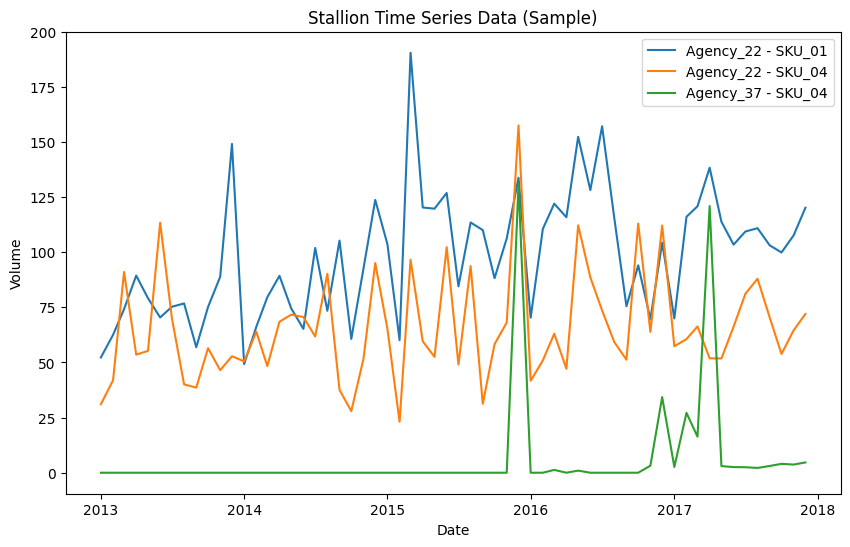

In [4]:
plt.figure(figsize=(10, 6))

for agency in data.agency.unique()[:2]:
    for sku in data.sku.unique()[:2]:
        series_data = data[(data.agency == agency) & (data.sku == sku)]
        if not series_data.empty:
            plt.plot(
                series_data.date,
                series_data.volume,
                label=f"{agency} - {sku}",
            )

plt.legend()
plt.title("Stallion Time Series Data (Sample)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

Create the training and validation datasets using `TimeSeriesDataSet`.

---

In [5]:
def get_datasets(data):
    max_prediction_length = 6
    max_encoder_length = 24
    training_cutoff = data["time_idx"].max() - max_prediction_length

    special_days = [
        "easter_day",
        "good_friday",
        "new_year",
        "christmas",
        "labor_day",
        "independence_day",
        "revolution_day_memorial",
        "regional_games",
        "fifa_u_17_world_cup",
        "football_gold_cup",
        "beer_capital",
        "music_fest",
    ]

    training = TimeSeriesDataSet(
        data[lambda x: x.time_idx <= training_cutoff],
        time_idx="time_idx",
        target="volume",
        group_ids=["agency", "sku"],
        min_encoder_length=max_encoder_length // 2,
        max_encoder_length=max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=max_prediction_length,
        static_categoricals=["agency", "sku"],
        static_reals=["avg_population_2017", "avg_yearly_household_income_2017"],
        time_varying_known_categoricals=["special_days", "month"],
        variable_groups={"special_days": special_days},
        time_varying_known_reals=["time_idx", "price_regular", "discount_in_percent"],
        time_varying_unknown_categoricals=[],
        time_varying_unknown_reals=[
            "volume",
            "log_volume",
            "industry_volume",
            "soda_volume",
            "avg_max_temp",
            "avg_volume_by_agency",
            "avg_volume_by_sku",
        ],
        target_normalizer=GroupNormalizer(
            groups=["agency", "sku"], transformation="softplus"
        ),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    validation = TimeSeriesDataSet.from_dataset(
        training, 
        data, 
        predict=True, 
        stop_randomization=True
    )

    return training, validation

Define the distributed training function utilizing the requested optimal TFT hyperparameters.

---

In [6]:
def train_func(config):
    data = ray.get(config["data_ref"])
    training, validation = get_datasets(data)

    pl.seed_everything(42, workers=True)

    dataloader_workers = config["dataloader_workers"]
    batch_size = 128

    train_dataloader = training.to_dataloader(
        train=True,
        batch_size=batch_size,
        num_workers=dataloader_workers,
    )

    val_dataloader = validation.to_dataloader(
        train=False,
        batch_size=batch_size,
        num_workers=dataloader_workers,
    )

    model = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=0.008430234162239324,
        hidden_size=24,
        attention_head_size=2,
        dropout=0.17465635788524705,
        hidden_continuous_size=12,
        loss=QuantileLoss(),
    )

    trainer = pl.Trainer(
        max_epochs=50,
        accelerator="gpu",
        devices="auto",
        gradient_clip_val=0.2721289279970094,
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        strategy=ray.train.lightning.RayDDPStrategy(),
        plugins=[ray.train.lightning.RayLightningEnvironment()],
        callbacks=[RayTrainReportCallback()],
    )

    trainer = ray.train.lightning.prepare_trainer(trainer)

    trainer.fit(
        model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader
    )

    with tempfile.TemporaryDirectory() as tmp_dir:
        checkpoint_path = Path(tmp_dir) / "checkpoint.ckpt"
        trainer.save_checkpoint(checkpoint_path)
        ray.train.report(metrics={}, checkpoint=Checkpoint.from_directory(tmp_dir))

Launch the distributed training job.

---

In [7]:
ray_trainer = TorchTrainer(
    train_func,
    train_loop_config={"data_ref": data_ref, "dataloader_workers": total_cpus - 1},
    scaling_config=scaling_config,
)

start_time = time.time()
result = ray_trainer.fit()
print(f"Distributed Training Time: {time.time() - start_time:.2f} seconds")

(TrainController pid=4059202) Requesting resources: {'CPU': 4, 'GPU': 1} * 4
(TrainController pid=4059202) Attempting to start training worker group of size 4 with the following resources: [{'CPU': 4, 'GPU': 1}] * 4
(RayTrainWorker pid=4059276) Setting up process group for: env:// [rank=0, world_size=4]
(TrainController pid=4059202) Started training worker group of size 4: 
(TrainController pid=4059202) - (ip=172.22.26.7, pid=4059276) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=4059202) - (ip=172.22.26.7, pid=4059277) world_rank=1, local_rank=1, node_rank=0
(TrainController pid=4059202) - (ip=172.22.26.8, pid=742537) world_rank=2, local_rank=0, node_rank=1
(TrainController pid=4059202) - (ip=172.22.26.8, pid=742536) world_rank=3, local_rank=1, node_rank=1
(RayTrainWorker pid=4059276) INFO: [rank: 0] Seed set to 42
(RayTrainWorker pid=4059276) [rank: 0] Seed set to 42
(RayTrainWorker pid=4059276) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-p

Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]


(RayTrainWorker pid=4059276) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('sanity_check_loss', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
(RayTrainWorker pid=4059276) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('sanity_check_SMAPE', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
(RayTrainWorker pid=4059276) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('sanity_check_MAE', ..., sync_dist=True)` when logging on epoch level in distributed

                                                                           
Epoch 0: 100%|██████████| 40/40 [00:03<00:00, 10.65it/s, train_loss_step=121.0]
(RayTrainWorker pid=4059276) 
Validation: |          | 0/? [00:00<?, ?it/s]
(RayTrainWorker pid=4059276) 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 0: 100%|██████████| 40/40 [00:04<00:00,  9.87it/s, train_loss_step=121.0, val_loss=184.0]


(RayTrainWorker pid=4059276) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('val_loss', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
(RayTrainWorker pid=4059276) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('val_SMAPE', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
(RayTrainWorker pid=4059276) /net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/result.py:433: It is recommended to use `self.log('val_MAE', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the 

...

Epoch 47: 100%|██████████| 40/40 [00:03<00:00, 10.81it/s, train_loss_step=41.70, val_loss=239.0, train_loss_epoch=47.20]
(RayTrainWorker pid=4059276) 
Validation: |          | 0/? [00:00<?, ?it/s]
(RayTrainWorker pid=4059276) 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 48: 100%|██████████| 40/40 [00:03<00:00, 10.44it/s, train_loss_step=40.60, val_loss=240.0, train_loss_epoch=45.30]
(RayTrainWorker pid=4059276) 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]
(RayTrainWorker pid=4059276) 
Epoch 48: 100%|██████████| 40/40 [00:04<00:00,  9.65it/s, train_loss_step=40.60, val_loss=242.0, train_loss_epoch=45.30]


(RayTrainWorker pid=742537, ip=172.22.26.8) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/net/people/plgrid/plgrmesek/ray_results/ray_train_run-2026-06-03_12-39-51/checkpoint_2026-06-03_12-43-35.373824) [repeated 8x across cluster]
(RayTrainWorker pid=742537, ip=172.22.26.8) Reporting training result 49: TrainingReport(checkpoint=Checkpoint(filesystem=local, path=/net/people/plgrid/plgrmesek/ray_results/ray_train_run-2026-06-03_12-39-51/checkpoint_2026-06-03_12-43-35.373824), metrics={'train_loss': 46.934207916259766, 'train_loss_step': 48.31922149658203, 'val_loss': 205.55828857421875, 'val_SMAPE': 0.5990889668464661, 'val_MAE': 269.80279541015625, 'val_RMSE': 721.8799438476562, 'val_MAPE': 35310944.0, 'train_loss_epoch': 46.934207916259766, 'epoch': 48, 'step': 1960}, validation=False) [repeated 8x across cluster]


Epoch 49: 100%|██████████| 40/40 [00:03<00:00, 10.92it/s, train_loss_step=41.80, val_loss=242.0, train_loss_epoch=46.50]
(RayTrainWorker pid=4059276) 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 49: 100%|██████████| 40/40 [00:03<00:00, 10.18it/s, train_loss_step=41.80, val_loss=230.0, train_loss_epoch=46.50]


(RayTrainWorker pid=4059276) INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
(RayTrainWorker pid=4059276) `Trainer.fit` stopped: `max_epochs=50` reached.
(RayTrainWorker pid=742537, ip=172.22.26.8) INFO: `weights_only` was not set, defaulting to `False`.
(RayTrainWorker pid=742537, ip=172.22.26.8) `weights_only` was not set, defaulting to `False`.
(RayTrainWorker pid=4059277) Reporting training result 51: TrainingReport(checkpoint=Checkpoint(filesystem=local, path=/net/people/plgrid/plgrmesek/ray_results/ray_train_run-2026-06-03_12-39-51/checkpoint_2026-06-03_12-43-39.600532), metrics={}, validation=False)


Epoch 49: 100%|██████████| 40/40 [00:04<00:00,  9.82it/s, train_loss_step=41.80, val_loss=230.0, train_loss_epoch=47.40]
Distributed Training Time: 232.90 seconds


Plot a sample of validation results (predictions vs actuals).

---

/net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seaml

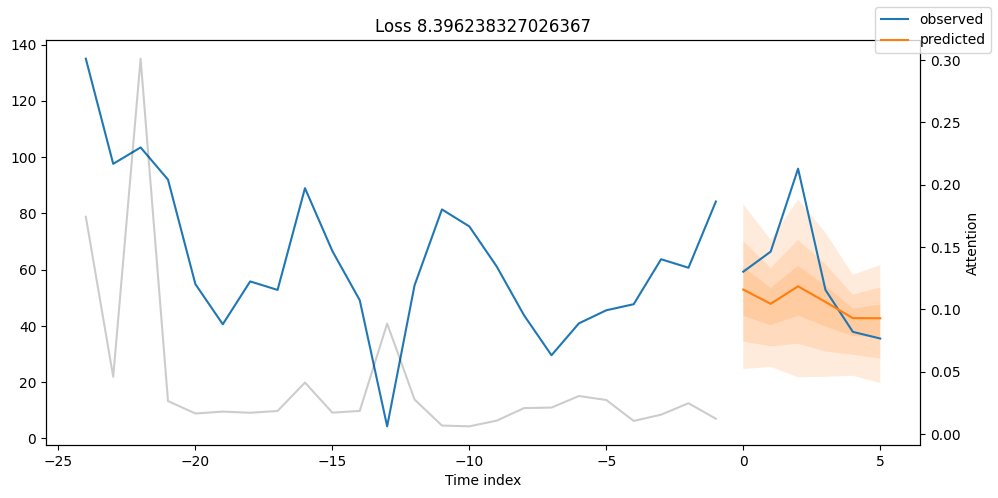

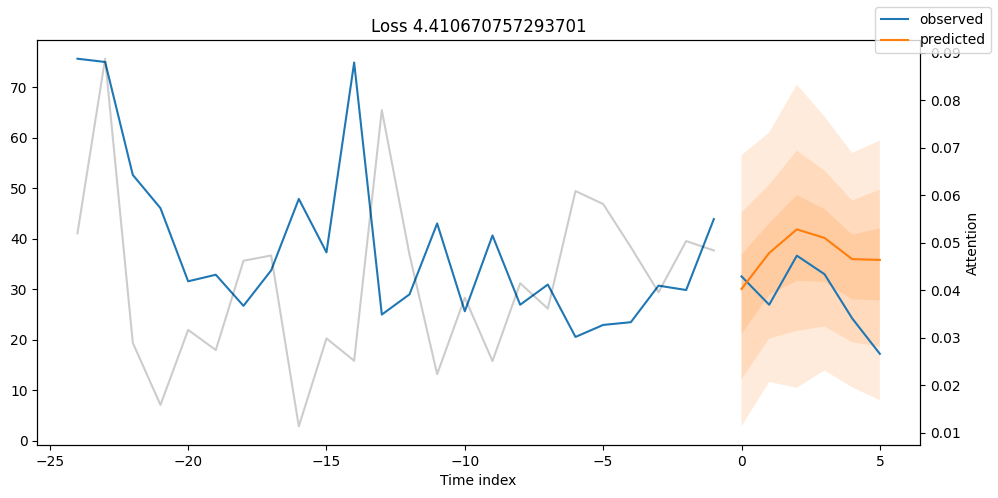

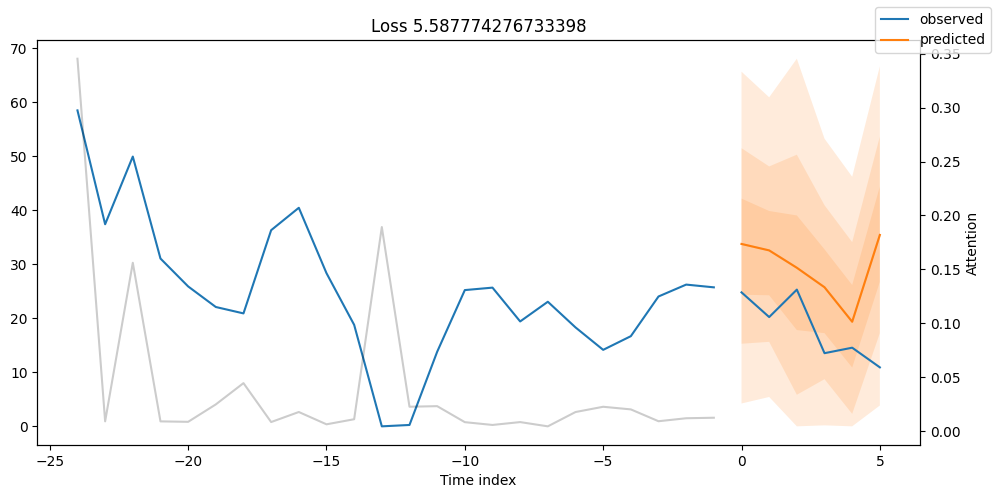

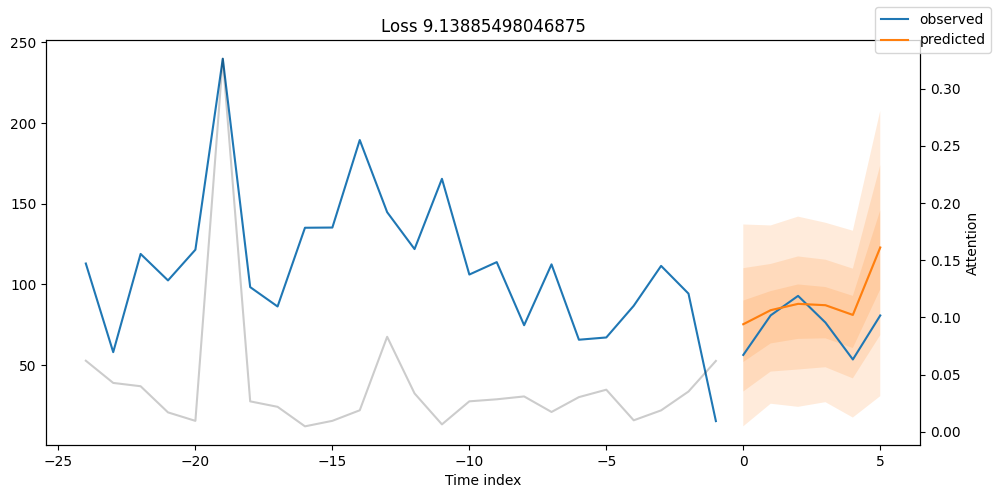

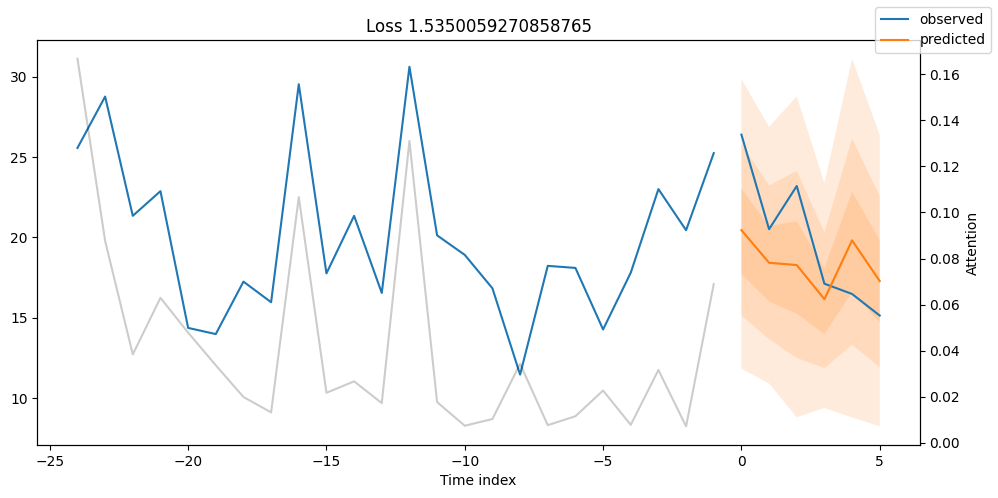

In [8]:
with result.checkpoint.as_directory() as checkpoint_dir:
    checkpoint_path = Path(checkpoint_dir) / "checkpoint.ckpt"
    best_model = TemporalFusionTransformer.load_from_checkpoint(checkpoint_path)

training, validation = get_datasets(data)
val_dataloader = validation.to_dataloader(train=False, batch_size=128, num_workers=0)

raw_predictions = best_model.predict(val_dataloader, mode="raw", return_x=True)

for idx in range(5):
    fig, ax = plt.subplots(figsize=(10, 5))
    best_model.plot_prediction(
        raw_predictions.x,
        raw_predictions.output,
        idx=idx,
        add_loss_to_title=True,
        ax=ax,
    )
    plt.show()

Actuals vs predictions by variables.

---

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
SLURM auto-requeueing enabled. Setting signal handlers.
/net/afscra/people/plgrmesek/.conda/envs/ray-cluster/lib/python3.12/site-packages/lightning/pytorch/train

{'avg_population_2017': <Figure size 1000x500 with 2 Axes>,
 'avg_yearly_household_income_2017': <Figure size 1000x500 with 2 Axes>,
 'encoder_length': <Figure size 1000x500 with 2 Axes>,
 'volume_center': <Figure size 1000x500 with 2 Axes>,
 'volume_scale': <Figure size 1000x500 with 2 Axes>,
 'time_idx': <Figure size 1000x500 with 2 Axes>,
 'price_regular': <Figure size 1000x500 with 2 Axes>,
 'discount_in_percent': <Figure size 1000x500 with 2 Axes>,
 'relative_time_idx': <Figure size 1000x500 with 2 Axes>,
 'volume': <Figure size 1000x500 with 2 Axes>,
 'log_volume': <Figure size 1000x500 with 2 Axes>,
 'industry_volume': <Figure size 1000x500 with 2 Axes>,
 'soda_volume': <Figure size 1000x500 with 2 Axes>,
 'avg_max_temp': <Figure size 1000x500 with 2 Axes>,
 'avg_volume_by_agency': <Figure size 1000x500 with 2 Axes>,
 'avg_volume_by_sku': <Figure size 1000x500 with 2 Axes>,
 'agency': <Figure size 1000x500 with 2 Axes>,
 'sku': <Figure size 1000x500 with 2 Axes>,
 'special_days'

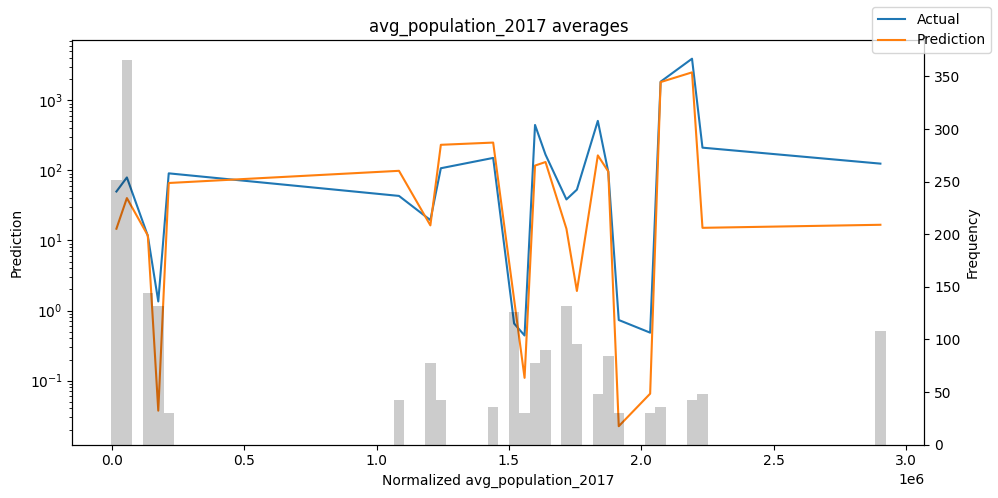

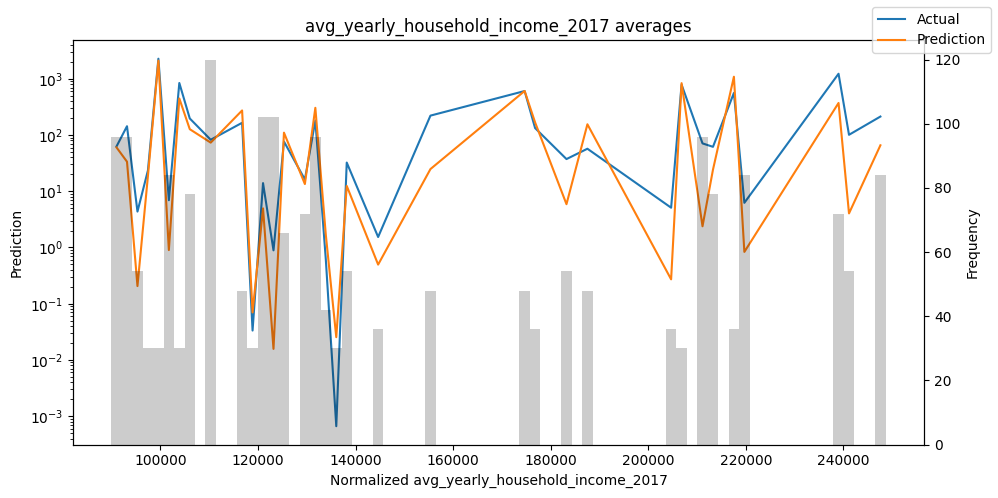

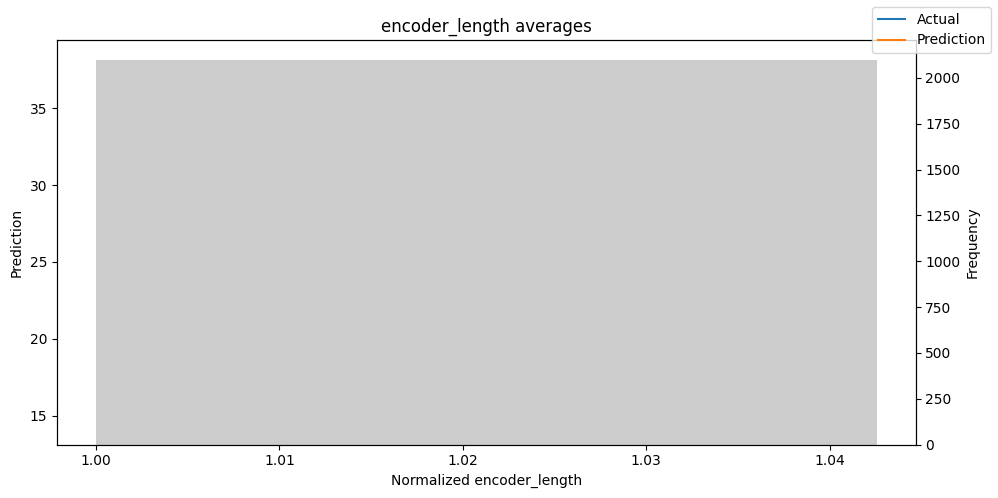

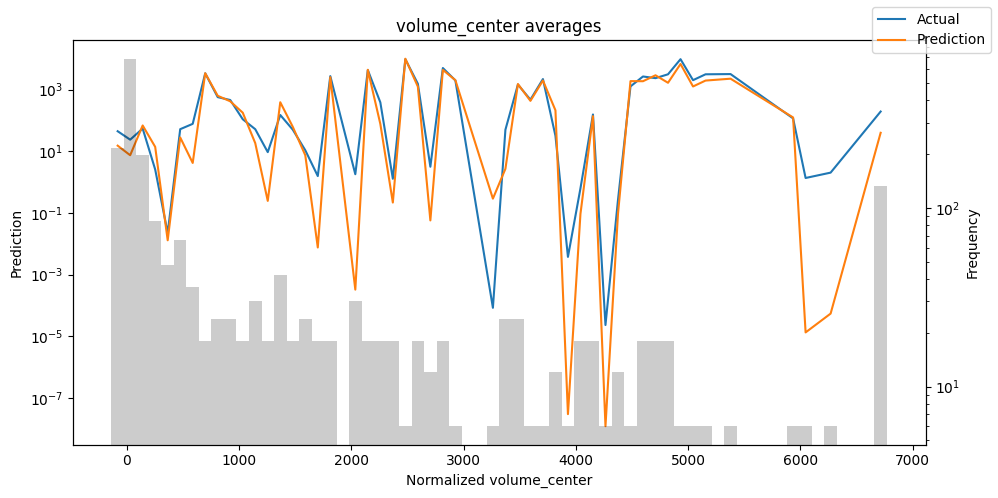

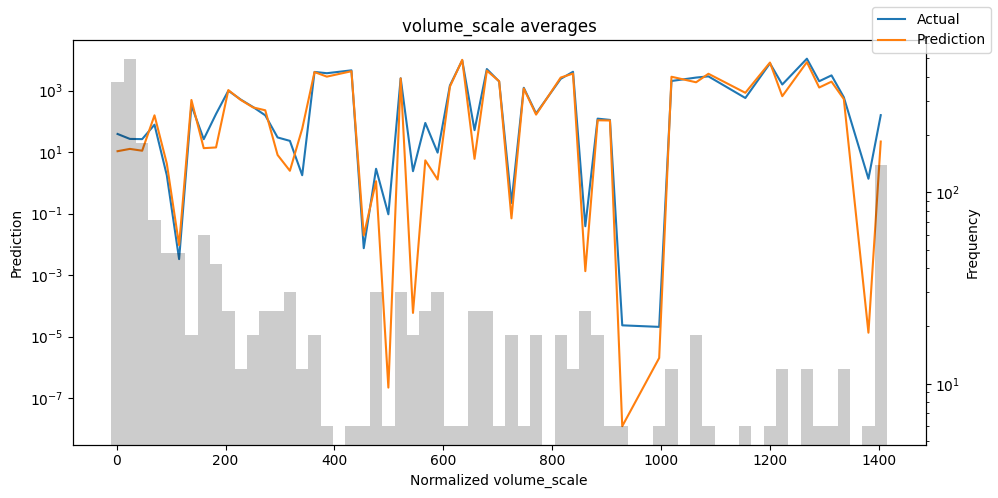

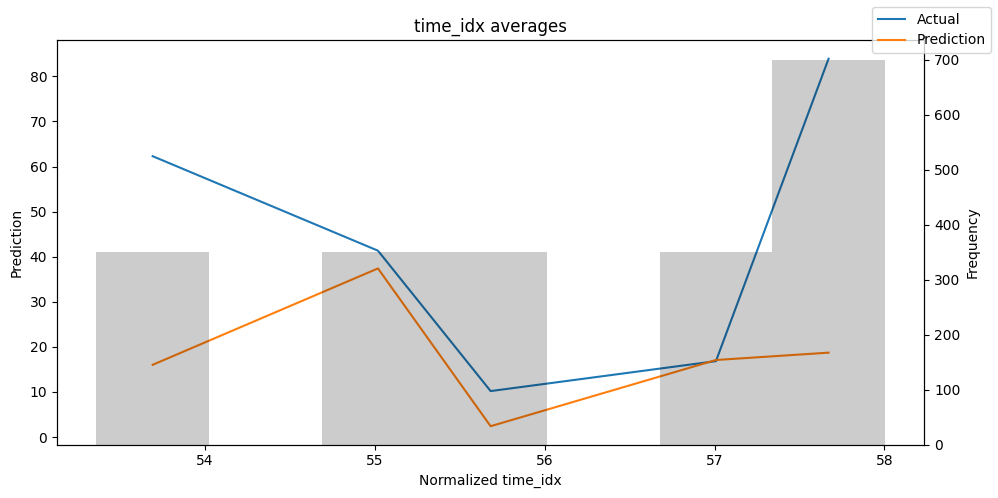

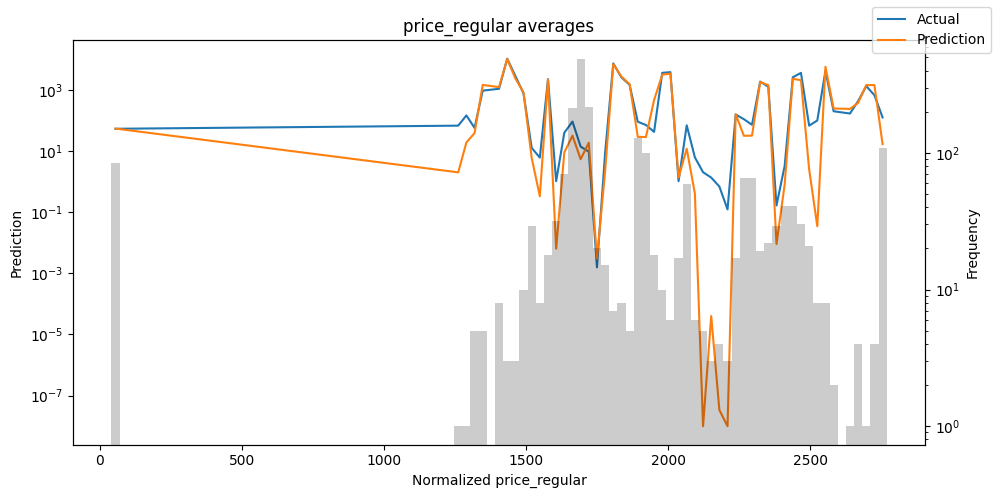

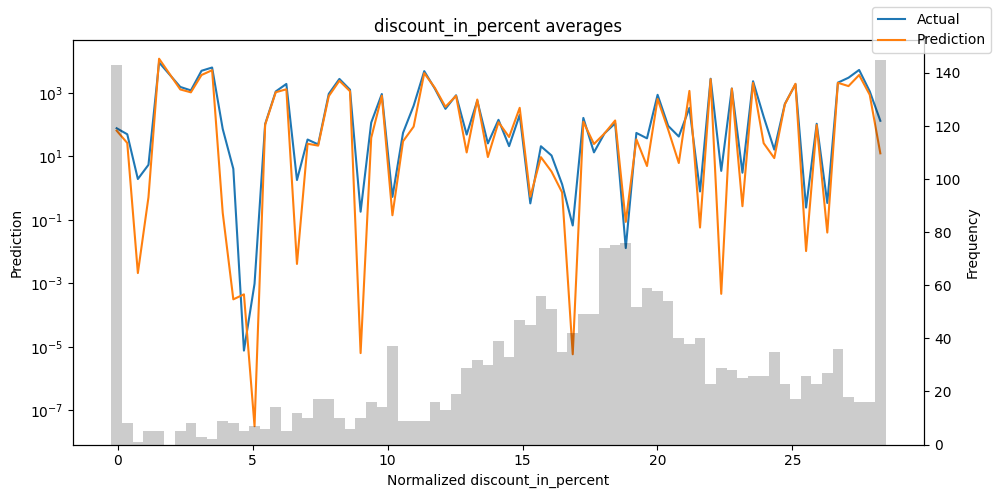

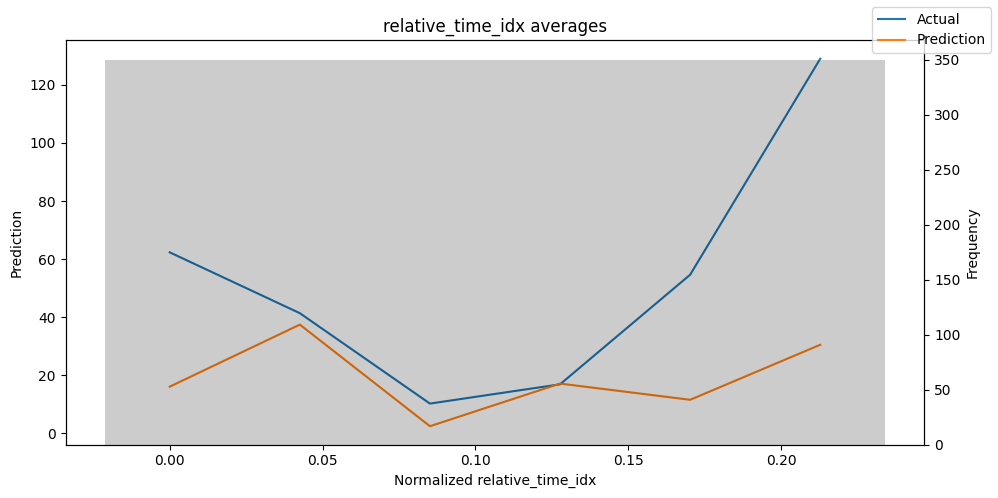

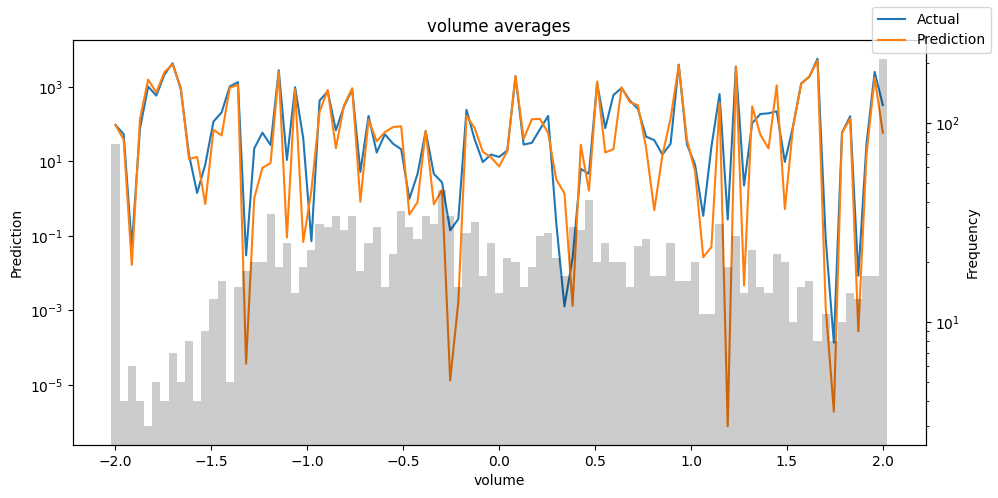

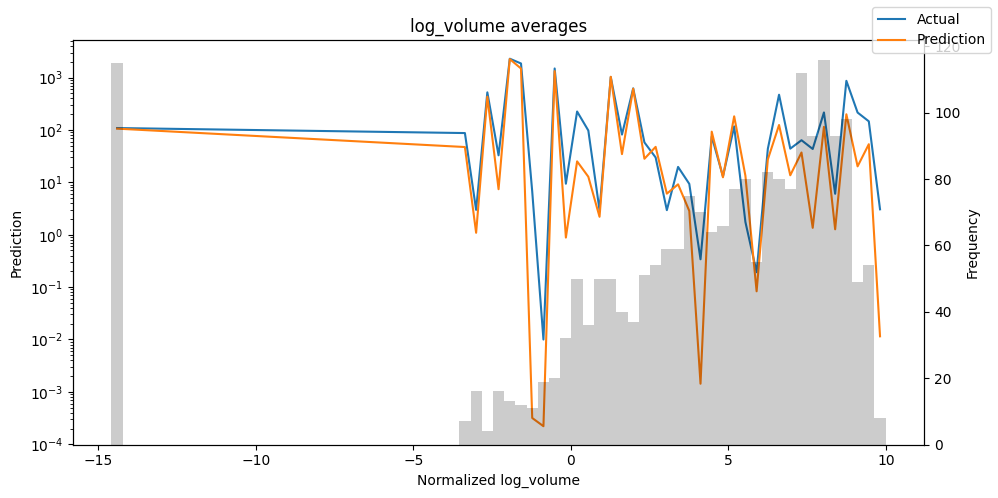

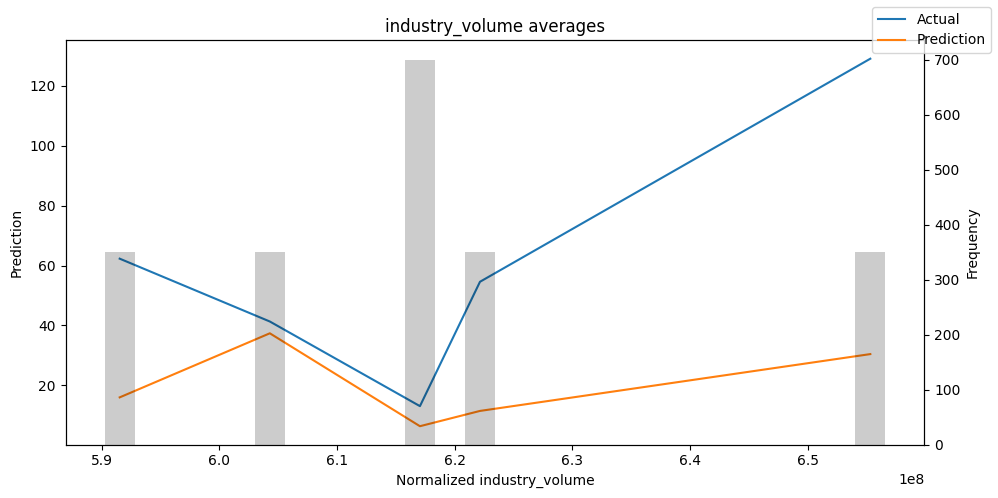

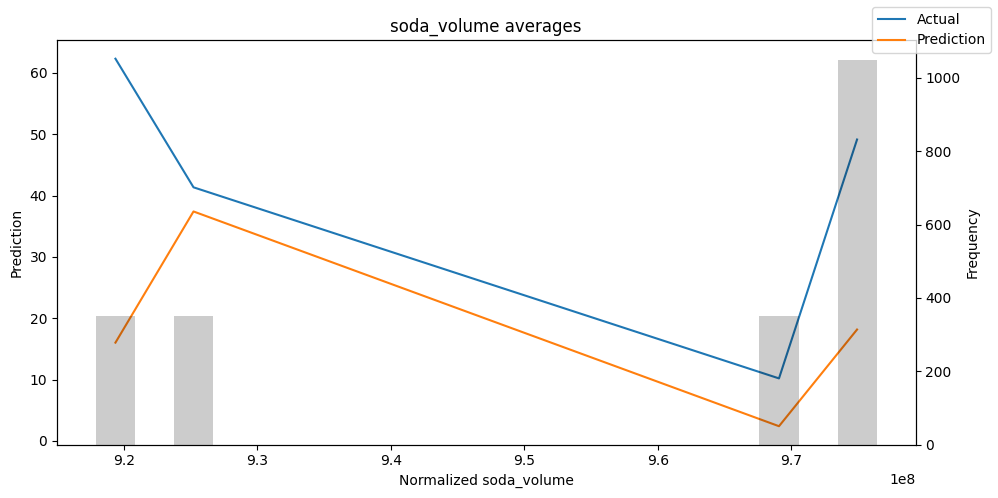

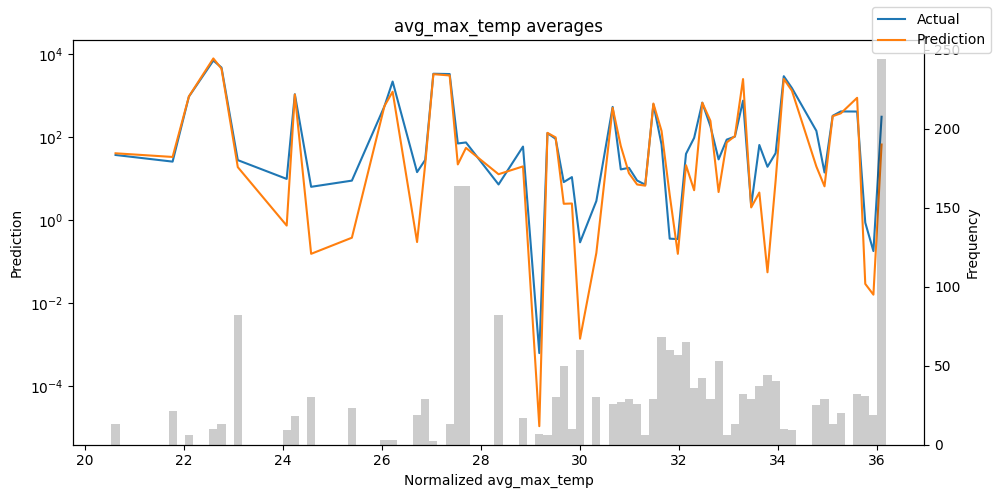

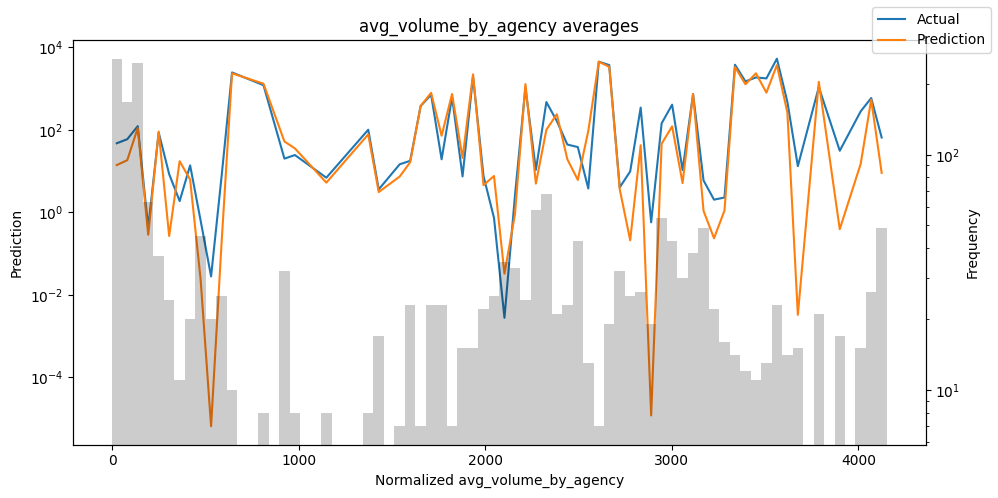

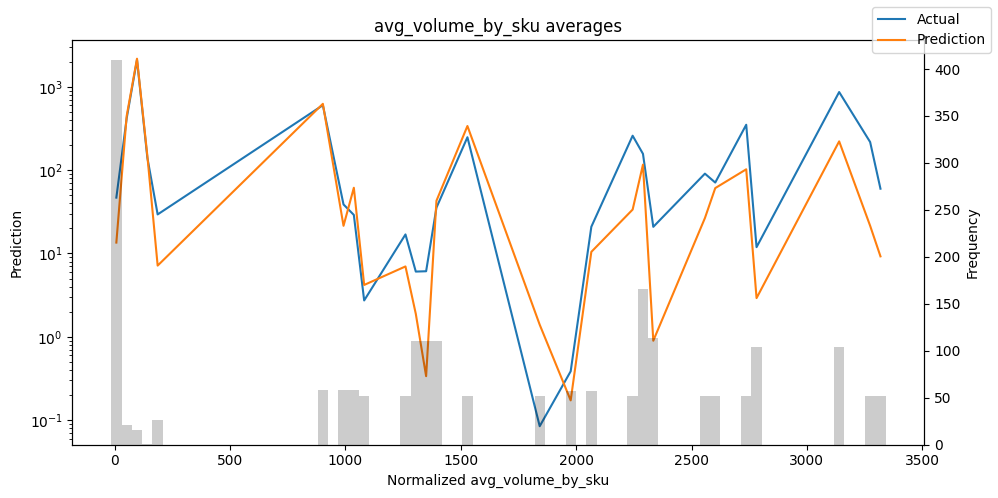

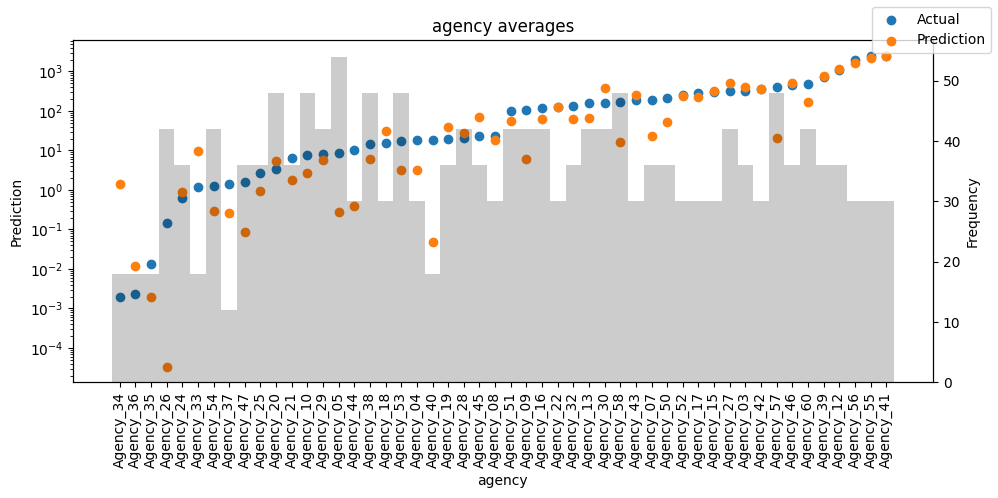

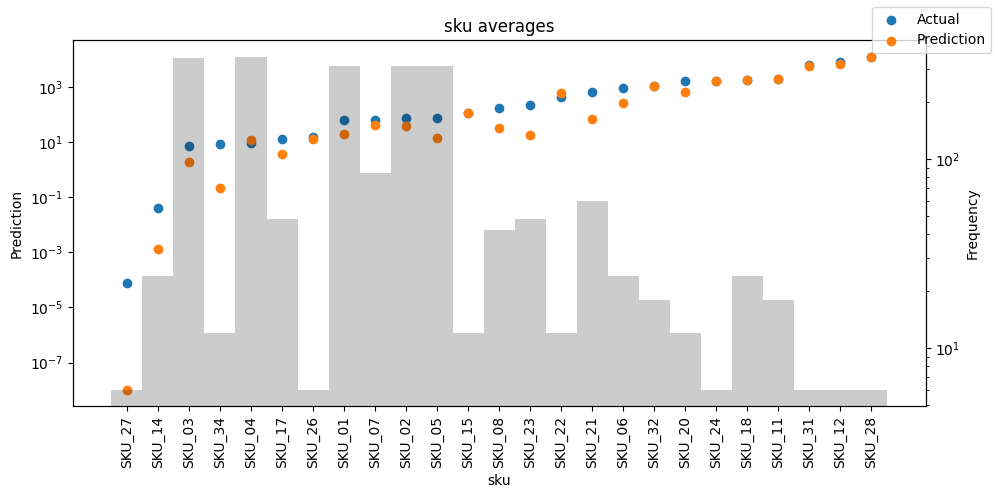

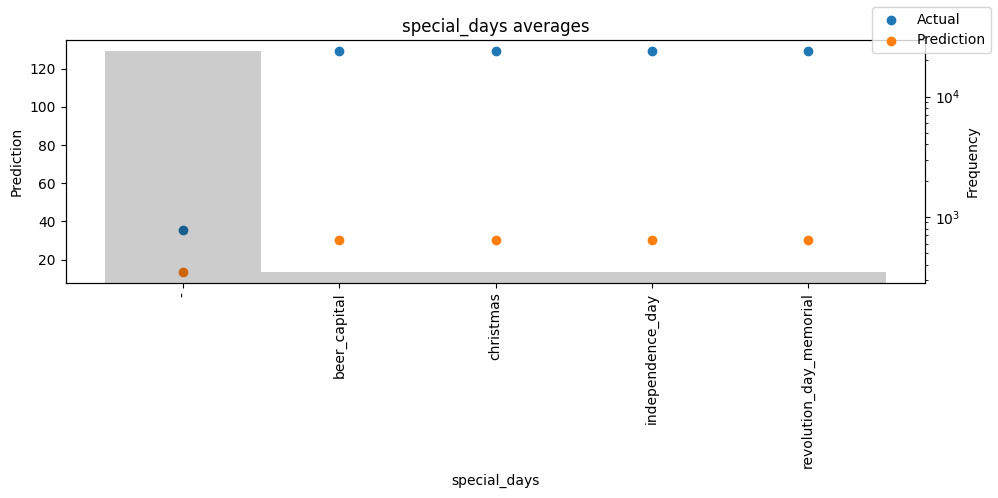

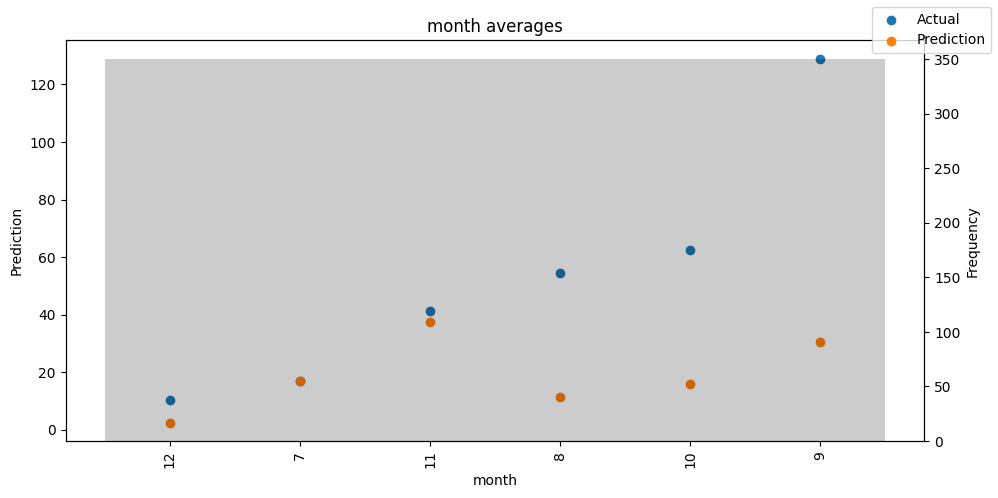

In [9]:
predictions = best_model.predict(val_dataloader, return_x=True)
predictions_vs_actuals = best_model.calculate_prediction_actual_by_variable(
    predictions.x, predictions.output
)

best_model.plot_prediction_actual_by_variable(predictions_vs_actuals)